In [1]:
# [Readable Mode] — complete, self-contained plotting script

import json, os
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [3]:
# ---------- Data loading ----------
try:
    residuals  # if already defined upstream (e.g., your notebook)
except NameError:
    with open("residuals.json", "r") as f:
        residuals = json.load(f)

In [4]:
# ---------- Config & styling ----------
# Marker per configuration (shape encodes config)
CONFIG_MARKERS = {
    "no-quant-20": "o",   # ● Full precision, 20 frames
    "no-quant":    "s",   # ■ Full precision, 2 frames
    "input-dig":   "v",   # ▼ Digitized inputs
    "wb-quant":    "^",   # ▲ Quantized network params
}
def _marker_for_config(cfg):
    return CONFIG_MARKERS.get(cfg, "o")

# Pretty variable labels
vbl_names = {'x': 'x', 'y': 'y', 'A': r'$\alpha$', 'B': r'$\beta$'}

# Errorbar styling for slide readability
ERR_STYLE = dict(capsize=3, capthick=1.0, elinewidth=1.2)

# Family → color (color encodes model family)
FAMILY_COLORS = {
    "Full Conv2D": "C0",
    "Max Conv2D":  "C1",
    "Slim Conv2D": "C2",
    "Full 1DConv": "C3",
    "Slim 1DConv": "C4",
    "Full MLP":    "C5",
    "Slim MLP":    "C6",
}
def _color_for_family(label):
    return FAMILY_COLORS.get(label, "C7")

# ---------- Schema helpers ----------
def _resolve_vbl_name(vbl):
    if vbl == 'A': return 'alpha'
    if vbl == 'B': return 'beta'
    return vbl

def _extract_stats(d, vbl_resolved):
    """
    Return: mean, down68, up68, has_pred_band, pred_down, pred_up
    Supports:
      - Flat keys: mean_x, down68_x, up68_x, mean_downsigmax, mean_upsigmax
      - Nested triplet: d['x'] = [mean, down68, up68]
    """
    k_mean = f"mean_{vbl_resolved}"
    k_dn   = f"down68_{vbl_resolved}"
    k_up   = f"up68_{vbl_resolved}"
    k_pdn  = f"mean_downsigma{vbl_resolved}"
    k_pup  = f"mean_upsigma{vbl_resolved}"

    if k_mean in d and k_dn in d and k_up in d:
        mean, dn, up = d[k_mean], d[k_dn], d[k_up]
        if k_pdn in d and k_pup in d:
            return mean, dn, up, True, d[k_pdn], d[k_pup]
        return mean, dn, up, False, None, None

    if vbl_resolved in d and isinstance(d[vbl_resolved], (list, tuple)):
        arr = d[vbl_resolved]
        mean = arr[0] if len(arr) > 0 else 0.0
        if len(arr) >= 3:
            dn, up = arr[1], arr[2]
        elif len(arr) == 2:
            dn = up = arr[1]
        else:
            dn = up = 0.0
        return mean, dn, up, False, None, None

    return None, None, None, False, None, None

# ---------- Drawing primitives ----------
def _xlab(ax_ii, vbl):
    ax_ii.set_xlabel(vbl_names.get(vbl, vbl))
    ax_ii.axvline(0.0, lw=0.75, alpha=0.6)
    ax_ii.set_yticks([])

def draw_one_vbl(vbl, d, ax_ii, *, y_pos=0, marker="o", color="C0"):
    v = _resolve_vbl_name(vbl)
    mean, dn, up, has_pred, pdn, pup = _extract_stats(d, v)
    if mean is None:
        return [], []
    # central bar
    line1 = ax_ii.errorbar(x=[mean], y=[y_pos], xerr=[[dn],[up]],
                           linestyle='', color=color, **ERR_STYLE)
    lines = [line1]
    # optional wide band if present
    if has_pred:
        line2 = ax_ii.errorbar(x=[mean], y=[y_pos], xerr=[[pdn],[pup]],
                               linestyle='', color=color, elinewidth=8, alpha=0.15)
        lines.append(line2)
    # marker
    dot = ax_ii.scatter([mean], [y_pos], marker=marker, color=color, s=35)
    _xlab(ax_ii, vbl)
    return lines, [dot]

def draw_one_model(model_dict, ax, *, y_pos=0, is_slim=False, marker="o", color="C0"):
    if is_slim:
        l1, d1 = draw_one_vbl('x', model_dict, ax[1][0], y_pos=y_pos, marker=marker, color=color)
        l2, d2 = draw_one_vbl('y', model_dict, ax[1][1], y_pos=y_pos, marker=marker, color=color)
        l4, d4 = draw_one_vbl('B', model_dict, ax[1][3], y_pos=y_pos, marker=marker, color=color)  # beta
        lines = l1 + l2 + l4; dots = d1 + d2 + d4
    else:
        l1, d1 = draw_one_vbl('x', model_dict, ax[1][0], y_pos=y_pos, marker=marker, color=color)
        l2, d2 = draw_one_vbl('y', model_dict, ax[1][1], y_pos=y_pos, marker=marker, color=color)
        l3, d3 = draw_one_vbl('A', model_dict, ax[1][2], y_pos=y_pos, marker=marker, color=color)  # alpha
        l4, d4 = draw_one_vbl('B', model_dict, ax[1][3], y_pos=y_pos, marker=marker, color=color)  # beta
        lines = l1 + l2 + l3 + l4; dots = d1 + d2 + d3 + d4
    return lines, dots

# ---------- Layout helper ----------
def format_plot(ax, ncols=4):
    for j in range(ncols):
        ax[0, j].axis('off')
        # bottom row spines a bit thinner
        for spine in ax[1, j].spines.values():
            spine.set_linewidth(0.8)

/tmp/ipykernel_1172133/1861043041.py:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


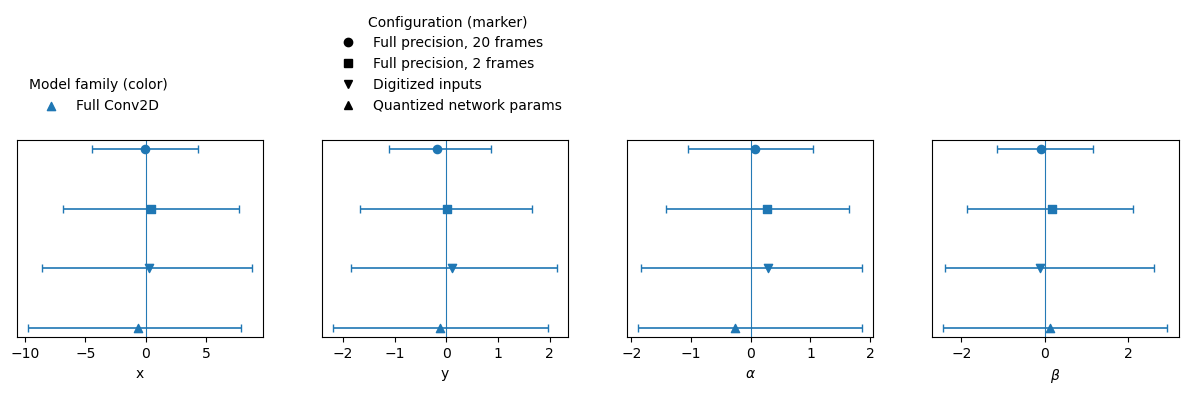

In [5]:
# ---------- WHAT to plot (edit this list to add families/configs) ----------
# (model_dict,              family_label,  is_slim,  config_key)
model_entries = [
    (residuals["full_2dconv"]["no-quant-20"], "Full Conv2D", False, "no-quant-20"),
    (residuals["full_2dconv"]["no-quant"],    "Full Conv2D", False, "no-quant"),
    (residuals["full_2dconv"]["input-dig"],   "Full Conv2D", False, "input-dig"),
    (residuals["full_2dconv"]["wb-quant"],    "Full Conv2D", False, "wb-quant"),
    # Example: add other families and they will get their family color automatically
    # (residuals["max_2dconv"]["no-quant-20"],  "Max Conv2D",  False, "no-quant-20"),
    # (residuals["slim_2dconv"]["input-dig"],   "Slim Conv2D", True,  "input-dig"),
]

# ---------- Build figure ----------
fig, ax = plt.subplots(2, 4, figsize=(12, 4), sharey=True,
                       constrained_layout=True, gridspec_kw={'height_ratios': [1, 3]})
format_plot(ax, 4)

# Legends: one per family (color) and one per config (marker)
family_handles, family_labels = [], []
cfg_handles = {
    "no-quant-20": mlines.Line2D([], [], linestyle='', marker='o', color='black'),
    "no-quant":    mlines.Line2D([], [], linestyle='', marker='s', color='black'),
    "input-dig":   mlines.Line2D([], [], linestyle='', marker='v', color='black'),
    "wb-quant":    mlines.Line2D([], [], linestyle='', marker='^', color='black'),
}
cfg_labels = {
    "no-quant-20": "Full precision, 20 frames",
    "no-quant":    "Full precision, 2 frames",
    "input-dig":   "Digitized inputs",
    "wb-quant":    "Quantized network params",
}

# Plot each entry at a distinct y position; spacing = 1 from top to bottom
# (top = len(entries)-1 ... bottom = 0) so it reads top→bottom in the panels
N = len(model_entries)
for row_idx, (m, fam_label, is_slim, cfg) in enumerate(model_entries[::-1]):
    y_pos = row_idx  # 0..N-1 bottom→top visually after reversing
    color = _color_for_family(fam_label)
    marker = _marker_for_config(cfg)
    lines, dots = draw_one_model(m, ax, y_pos=y_pos, is_slim=is_slim, marker=marker, color=color)
    # one handle per unique family label
    if dots and fam_label not in family_labels:
        family_handles.append(dots[0])
        family_labels.append(fam_label)

# Put legends in the top row
ax[0,0].legend(family_handles, family_labels, frameon=False, loc='lower left', title="Model family (color)")
ax[0,1].legend([cfg_handles[k] for k in CONFIG_MARKERS],
               [cfg_labels[k]  for k in CONFIG_MARKERS],
               frameon=False, loc='lower left', title="Configuration (marker)")

plt.tight_layout()
plt.show()